# Thermistor metrics

A notebook that is supposed to compute and plot different thermistor data metrics such as e.g. the penetration depth of the seasonl signal or the attenuation ratio

The analysis focuses on the tynitag (shallow borehole) data which includes 2 boreholes per glacier as it covers an entire hydrological year

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add project root to Python path
project_root = '/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from processing.thermistor_processing import *
from processing.gpr_plotting import format_plot

In [2]:
# set main icetemp data dir
TT_icetemp_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/NTC_tynitag/temperature_data/full_timeseries/"
TT_settings_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/thermistor_borehole_settings/"

# set output dir for figures
output_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/icetemp_results/geoprecision/"

# set tiny tag data dir
HS1TT_dir = TT_icetemp_dir + "HS1TT_20240808_20250927_spliced.csv" # HS1TT
HS2TT_dir = TT_icetemp_dir + "HS2TT_20240808_20250927_spliced.csv" # HS2TT
AH1TT_dir = TT_icetemp_dir + "AH1TT_20250322_20250916.csv" #AH1TT
AH2TT_dir = TT_icetemp_dir + "AH2TT_20240821_20250916_spliced.csv" #AH2TT
CJ1TT_dir = TT_icetemp_dir + "CJ1TT_20240809_20250808_spliced.csv" #CJ1TT
CJ2TT_dir = TT_icetemp_dir + "CJ2TT_20240809_20250808_spliced.csv" #CJ2TT
SR1TT_dir = TT_icetemp_dir + "SR1TT_20240806_20250724_spliced.csv" #SR1TT
SR2TT_dir = TT_icetemp_dir + "SR2TT_20240806_20250724_spliced.csv" #SR2TT
GT1TT_dir = TT_icetemp_dir + "GT1TT_20240807_20250723_spliced.csv" #GT1TT
GT2TT_dir = TT_icetemp_dir + "GT2TT_20240807_20250723_spliced.csv" #GT2TT
CT1TT_dir = TT_icetemp_dir + "CT1TT_20240828_20250905.csv" #CT1TT
CT2TT_dir = TT_icetemp_dir + "CT2TT_20240828_20250905_spliced.csv" #CT2TT

## set path to current depth file

# Chessjen depth files
depth_CJ1TT = TT_settings_dir + "thermistor_settings_cj1tt.csv"
depth_CJ2TT = TT_settings_dir + "thermistor_settings_cj2tt.csv"

# Alphubel depth files
depth_AH1TT = TT_settings_dir + "thermistor_settings_ah1tt.csv"
depth_AH2TT = TT_settings_dir + "thermistor_settings_ah2tt.csv"

# Hohsaas depth files
depth_HS1TT = TT_settings_dir + "thermistor_settings_hs1tt.csv"
depth_HS2TT = TT_settings_dir + "thermistor_settings_hs2tt.csv"

# Sex Rouges depth files
depth_SR1TT = TT_settings_dir + "thermistor_settings_sr1tt.csv"
depth_SR2TT = TT_settings_dir + "thermistor_settings_sr2tt.csv"

# Glacier de Tortin depth files
depth_GT1TT = TT_settings_dir + "thermistor_settings_gt1tt.csv"
depth_GT2TT = TT_settings_dir + "thermistor_settings_gt2tt.csv"

# Corvatsch depth files
depth_CT1TT = TT_settings_dir + "thermistor_settings_ct1tt.csv"
depth_CT2TT = TT_settings_dir + "thermistor_settings_ct2tt.csv"

## generate a thermistor data object

# Chessjen boreholes
CJ1TT = ThermistorData(CJ1TT_dir, ",", depth_CJ1TT)
CJ2TT = ThermistorData(CJ2TT_dir, ",", depth_CJ2TT)

# Alphubel boreholes
AH1TT = ThermistorData(AH1TT_dir, ",", depth_AH1TT)
AH2TT = ThermistorData(AH2TT_dir, ",", depth_AH2TT)

# Hohsaas boreholes (HS)
HS1TT = ThermistorData(HS1TT_dir, ",", depth_HS1TT)
HS2TT = ThermistorData(HS2TT_dir, ",", depth_HS2TT)

# Sex Rouges boreholes (SR)
SR1TT = ThermistorData(SR1TT_dir, ",", depth_SR1TT)
SR2TT = ThermistorData(SR2TT_dir, ",", depth_SR2TT)

# Glacier de Tortin boreholes (GT)
GT1TT = ThermistorData(GT1TT_dir, ",", depth_GT1TT)
GT2TT = ThermistorData(GT2TT_dir, ",", depth_GT2TT)

# Corvatsch boreholes (CT)
CT1TT = ThermistorData(CT1TT_dir, ",", depth_CT1TT)
CT2TT = ThermistorData(CT2TT_dir, ",", depth_CT2TT)

In [4]:
# TinyTag offsets (0°C offsets)
offsets_TT_path = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/NTC_tynitag/calibration_data/all_logger_offsets.csv"
offsets_TT = pd.read_csv(offsets_TT_path)

# Define TinyTag entries (adjust logger_id if needed)
tt_entries = [
    {"name": "HS1TT", "glacier": "Hohsaas", "thermistor": HS1TT, "logger_id": "5",  "depth_file": depth_HS1TT},
    {"name": "HS2TT", "glacier": "Hohsaas", "thermistor": HS2TT, "logger_id": "6",  "depth_file": depth_HS2TT},
    {"name": "AH1TT", "glacier": "Alphubel","thermistor": AH1TT, "logger_id": "9",  "depth_file": depth_AH1TT},
    {"name": "AH2TT", "glacier": "Alphubel","thermistor": AH2TT, "logger_id": "10",  "depth_file": depth_AH2TT},
    {"name": "CJ1TT", "glacier": "Chessjen","thermistor": CJ1TT, "logger_id": "7",  "depth_file": depth_CJ1TT},
    {"name": "CJ2TT", "glacier": "Chessjen","thermistor": CJ2TT, "logger_id": "8",  "depth_file": depth_CJ2TT},
    {"name": "SR1TT", "glacier": "SexRouges","thermistor": SR1TT, "logger_id": "1",  "depth_file": depth_SR1TT},
    {"name": "SR2TT", "glacier": "SexRouges","thermistor": SR2TT, "logger_id": "2",  "depth_file": depth_SR2TT},
    {"name": "GT1TT", "glacier": "Tortin","thermistor": GT1TT, "logger_id": "3",  "depth_file": depth_GT1TT},
    # {"name": "GT2TT", "glacier": "Tortin","thermistor": GT2TT, "logger_id": "4",  "depth_file": depth_GT2TT}, # thermistors not working
    {"name": "CT1TT", "glacier": "Corvatsch","thermistor": CT1TT, "logger_id": "11",  "depth_file": depth_CT1TT},
    # {"name": "CT2TT", "glacier": "Corvatsch","thermistor": CT2TT, "logger_id": "12",  "depth_file": depth_CT2TT}, # only one thermistor working
]
# TODO: Fill the "?" logger IDs.

# Window covering the hydrological year
win = dict(start_time="01.09.2024 00:00:00", end_time="30.09.2025 00:00:00")

# Compute ZAA per TinyTag borehole
metrics_zaa = compute_tynitag_zaa_batch(tt_entries, offsets_TT, zaa_threshold=0.1, zaa_extrapolate=True, **win)

# Aggregate by glacier for the summary plot
summary_zaa = summarize_zaa_by_glacier(metrics_zaa)
summary_zaa

,glacier,zaa_mean,zaa_min,zaa_max,n,zaa_range
0,Alphubel,12.863730,12.253664,13.473796,2,1.220132
1,Chessjen,9.943431,9.528424,10.358439,2,0.830015
2,Corvatsch,8.092865,8.092865,8.092865,1,0.000000
3,Hohsaas,11.869186,10.373613,13.364758,2,2.991145
4,SexRouges,11.766214,10.966686,12.565743,2,1.599056
5,Tortin,8.120112,8.120112,8.120112,1,0.000000


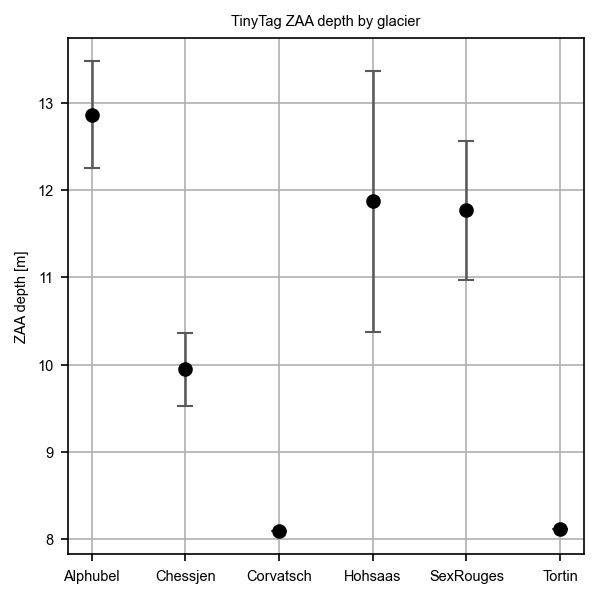

In [5]:
# Plot summary of ZAA by glacier
df = summary_zaa.sort_values("glacier").reset_index(drop=True)
glaciers = df["glacier"].tolist()
x = np.arange(len(glaciers))
y = df["zaa_mean"].to_numpy()
yerr = 0.5 * df["zaa_range"].fillna(0).to_numpy()

fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=150)
ax.errorbar(
    x, y, yerr=yerr,
    fmt="o", color="k",
    ecolor="0.35", elinewidth=1.2, capsize=4,
    label="Mean ± range/2"
)
ax.set_ylabel("ZAA depth [m]")
ax.set_xticks(x)
ax.set_xticklabels(glaciers, rotation=0)

format_plot(ax=ax, title="TinyTag ZAA depth by glacier",
            legend_loc="upper right", x_tick_rotation=0,
            adjust_linewidths=False)
plt.show()